# E10 - structure-sensitive, content-invariant document distances

Executes the pre-registered **E10 batch** (`## E10 - structure-sensitive, content-invariant distance`).
E08 left two surviving structure reads, each missing exactly one half of the property we want:

- **E08-H44** position-augmented Wasserstein - scramble-monotone (rises through full scramble) but **not
  translation-invariant** (reads a pure positional shift as disorder; the absolute-position failure)
- **E08-H45** positional Fused Gromov-Wasserstein - translation-invariant (pure shift $\approx 0$) but
  **collapses at extreme reorder** (the Gromov isometry-invariance reasserts; not monotone through the top bin)

E10 tests five mechanisms whose design intent is to hold **both** properties at once - rise smoothly through
the **top** displacement bin **and** read $\approx 0$ on a pure positional shift - while staying blind to a
content paraphrase. The decisive question per hypothesis: does it achieve **translation-invariance
(shift $\approx 0$) AND scramble-monotonicity (rises through the top bin) together**, the combined property
neither E08 survivor held, while reading $\approx 0$ on the paraphrase control.

**The five mechanisms**

- **E10-H54** content-pinned Gromov distortion - the GW structure term scored on the **content-pinned**
  transport plan $T$ (not re-optimized), so a reorder cannot escape to the GW isometry. A **score**
- **E10-H55** OPW order-gap - Su & Hua order-preserving Wasserstein (Sinkhorn) minus SMD; the extra cost of
  order regularization. A **score** (KL temporal prior $\rightarrow$ a divergence)
- **E10-H56** source-anchored ordering divergence - Kendall-tau-sequence distance between the two documents'
  reading-order sequences of shared source-bin indices. A **metric**
- **E10-H57** shared-codebook edit distance - co-cluster pooled statements into shared symbols, read
  Kendall-tau-sequence between the two symbol strings (table-turning, non-OT). A **metric**
- **E10-H58** soft-DTW divergence order-gap - Blondel-Mensch-Vert soft-DTW divergence minus SMD; the
  monotonic-alignment cost above the order-free OT. A **score**

**Regimes** - the same evaluation for every measure: the byte-identical **reorder pool** per displacement bin
(scramble-monotonicity), the **pure-shift** perturbation (translation-invariance), an embedding-space
**paraphrase proxy** (content-invariance, a deferral - no API key), the realistic **cross-summary** diffuse
pairs, a **triangle** check, and the E08-H44 (position-augmented Wasserstein) / naive greedy-1-NN
**baselines** on the two discriminating axes. Output - per-hypothesis figures, an `e10-summary` panel, and
`reports/E10-structure-sensitive-metrics.json`.

## GPU selection

mmBERT statement embedding runs on the RTX 5000 Ada (GPU 2) by UUID, the same device E07/E08 used, so the
embeddings are byte-comparable. The workload is tiny (~150 statements) and every distance is CPU numpy /
POT, so the GPU only accelerates the one embedding pass.

In [1]:
import os
# RTX 5000 Ada (GPU 2) by UUID - same device E08 used; all OT is CPU numpy
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
# resolve the freest GPU and pin it by UUID (portable - never a hardcoded index)
import subprocess as _sp
def _free_gpu_uuid():
    try:
        rows = _sp.check_output(
            ["nvidia-smi", "--query-gpu=uuid,memory.used,utilization.gpu", "--format=csv,noheader,nounits"],
            text=True).strip().splitlines()
        gpus = [(u.strip(), int(mu), int(ut)) for u, mu, ut in (r.split(",") for r in rows)]
        return min(gpus, key=lambda g: (g[2], g[1]))[0] if gpus else None
    except Exception:
        return None
_gpu = _free_gpu_uuid()
if _gpu:
    os.environ["CUDA_VISIBLE_DEVICES"] = _gpu
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import warnings; warnings.filterwarnings("ignore")
import torch
print("torch", torch.__version__, "| cuda:", torch.cuda.is_available(), "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

torch 2.12.1+cu130 | cuda: True | NVIDIA RTX 5000 Ada Generation


## Imports

In [2]:
%load_ext autoreload
%autoreload 2

import json
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from rich.console import Console
from rich.table import Table
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

import ot
from docdistance.distance import (
    cost_matrix, transport_plan, smd, closeness, coverage_alignment, SMD_MAX,
)
from docdistance.encoders import load_encoder

console = Console()
sns.set_theme(style="whitegrid", context="notebook")
print("imports ready | POT", ot.__version__)

imports ready | POT 0.9.6.post1


## Reproducibility

In [3]:
SEED = 0
np.random.seed(SEED)
print(f"SEED={SEED}")

SEED=0


## Configuration

Loads the E07/E08 fixture `data/processed/structure-fixture/`, embeds every document once under the **raw
single-pair regime** (mmBERT mean-pooled, L2-normalized, no corpus-wide anisotropy - the production regime
the design gates on), and fixes the pre-registered bars. The byte-identical reorder pool is the
order-isolation **upper bound**; the natural cross-summary pairs are the realistic diffuse-$T$ regime.

The source anchor for E10-H56 is the fixture's pre-segmented **source article** (`source`, 62 statements) -
identical to `data/interim/exec-summaries/ibm-ai-adoption/source`, embedded the same way as the summaries so
the coverage alignment is byte-comparable to E08.

In [4]:
ROOT = Path("/home/lab/workspace/learning/projects/docdistance")
FIX = ROOT / "data/processed/structure-fixture"
DOCSTORE = json.load(open(FIX / "statements.json"))
REORDER = json.load(open(FIX / "reorder_pool.json"))
PAIRS = json.load(open(FIX / "pairs.json"))
if isinstance(PAIRS.get("cross_summary"), dict):  # per-article dict -> flat list (E07-E10 predate the grouping)
    PAIRS["cross_summary"] = [p for v in PAIRS["cross_summary"].values() for p in v]
META = json.load(open(FIX / "meta.json"))

N_BINS = META["n_bins"]
BASE_DOCS = META["base_docs"]
EDGES = np.linspace(0.0, 1.0, N_BINS + 1)
CENTERS = (EDGES[:-1] + EDGES[1:]) / 2
PER_BIN = 12                       # perms sampled per displacement bin per base (matches E08)
SHIFTS = [2, 4]                    # pure-shift magnitudes (rigid positional translation, from E08)
GAMMA = 0.1                        # E10-H58 soft-DTW temperature (Blondel-Mensch-Vert default)
OPW_L1, OPW_L2, OPW_SIGMA = 50.0, 0.1, 1.0   # E10-H55 Su & Hua OPW defaults
PARA_COS = 0.875                   # E10 paraphrase proxy target mean cosine (drops to 0.85-0.90 band)
PARA_DRAWS = 8                     # noise draws per base for the paraphrase-control distribution
CODEBOOK_THRESH = 0.60             # E10-H57 agglomerative codebook distance threshold on sqrt(2-2cos)
LAM_BASE = 0.25                    # E08-H44 position-augmented Wasserstein baseline lambda
MONO_BAR = 0.90                    # scramble Spearman bar
CONTENT_FRAC = 0.10                # content-invariance bar: paraphrase p95 <= this * reorder top-bin mean
TRI_TRIALS = 150
TOL = 1e-9

FIGDIR = ROOT / "reports/figures/E10"; FIGDIR.mkdir(parents=True, exist_ok=True)
REPORT = ROOT / "reports/E10-structure-sensitive-metrics.json"

# embed each document once - raw embeddings, no anisotropy (production single-pair regime, as E08)
ENC = load_encoder("torch", offline=False, device="cuda")
EMB = {label: ENC.encode(DOCSTORE[label]["statements"]) for label in DOCSTORE}
ES = EMB["source"]                 # shared source anchor for E10-H56
DEVICE = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

RESULTS, VERDICTS = {}, {}

# per-hypothesis colors
COL = {"h54": "#d62728", "h55": "#9467bd", "h56": "#17becf", "h57": "#bcbd22", "h58": "#8c564b",
       "paug": "#e8743b", "naive": "#6c757d", "shift": "#2ca02c", "para": "#e8743b", "chance": "#222222"}

t = Table(title="E10 configuration", title_style="bold cyan", show_header=False, box=None, padding=(0, 2))
t.add_column(style="bold cyan"); t.add_column()
t.add_row("Device", DEVICE)
t.add_row("Fixture", f"{len(DOCSTORE)} docs, {sum(len(v) for v in REORDER.values())} reorder perms, "
                     f"{len(PAIRS['cross_summary'])} cross-summary pairs, source {len(ES)} statements")
t.add_row("Embedding", "mmBERT raw single-pair (no anisotropy)")
t.add_row("Displacement bins", f"{N_BINS} equal-width, {PER_BIN}/bin/base, centers {np.round(CENTERS,2).tolist()}")
t.add_row("Mechanisms", "H54 pinned-GW (score) | H55 OPW gap (score) | H56 source Kendall-tau (metric) | "
                        "H57 codebook edit (metric) | H58 soft-DTW gap (score)")
t.add_row("Baselines", f"E08-H44 posaug Wasserstein (lambda={LAM_BASE}) | naive greedy 1-NN")
t.add_row("New-property bars", f"shift <= paraphrase p95 (translation-invariance); rises through top bin & "
                               f"Spearman>={MONO_BAR} (scramble-monotonicity); paraphrase p95 <= "
                               f"{CONTENT_FRAC:g} x top-bin (content-invariance)")
console.print(t)
print("embedded", len(EMB), "docs | dim", next(iter(EMB.values())).shape[1])

                                                 E10 configuration                                                 
  Device               NVIDIA RTX 5000 Ada Generation                                                              
  Fixture              12 docs, 1274 reorder perms, 55 cross-summary pairs, source 62 statements                   
  Embedding            mmBERT raw single-pair (no anisotropy)                                                      
  Displacement bins    6 equal-width, 12/bin/base, centers [0.08, 0.25, 0.42, 0.58, 0.75, 0.92]                    
  Mechanisms           H54 pinned-GW (score) | H55 OPW gap (score) | H56 source Kendall-tau (metric) | H57         
                       codebook edit (metric) | H58 soft-DTW gap (score)                                           
  Baselines            E08-H44 posaug Wasserstein (lambda=0.25) | naive greedy 1-NN                                
  New-property bars    shift <= paraphrase p95 (translation-invariance); rises through top bin & Spearman>=0.9     
                       (scramble-monotonicity); paraphrase p95 <= 0.1 x top-bin (content-invariance)

embedded 12 docs | dim 768


## Mechanisms and shared reads

`pos_vec(n) = arange(n)/max(n-1,1)` is the normalized reading position. Every mechanism operates on
L2-normalized statement embeddings with the shipped `cost_matrix` / `transport_plan` / `smd` /
`coverage_alignment` and the metric ground cost $\sqrt{2-2\cos}$. The E08-H44 `posaug_smd` and the naive
greedy-1-NN read are carried over verbatim as the two discriminating baselines.

In [5]:
def pos_vec(n):
    return np.arange(n) / max(n - 1, 1)

# --- E08-H44 baseline: position-augmented Wasserstein (uses ABSOLUTE position) ---
def posaug_cost(EA, EB, lam, posA=None, posB=None):
    d_sem = cost_matrix(EA, EB)
    pa = pos_vec(len(EA)) if posA is None else posA
    pb = pos_vec(len(EB)) if posB is None else posB
    d_pos = np.abs(pa[:, None] - pb[None, :])
    return np.sqrt((1 - lam) * d_sem ** 2 + lam * d_pos ** 2)

def posaug_smd(EA, EB, lam, posA=None, posB=None):
    a, b = np.full(len(EA), 1 / len(EA)), np.full(len(EB), 1 / len(EB))
    return float(ot.emd2(a, b, posaug_cost(EA, EB, lam, posA, posB)))

# --- naive greedy-1-NN baseline (E07/E08 verbatim): footrule of the content-nearest assignment ---
def norm_footrule_ranks(order):
    n = len(order)
    if n < 2:
        return 0.0
    return float(np.abs(np.asarray(order) - np.arange(n)).sum()) / (n * n // 2)

def naive_order(EA, EB):
    return np.argsort(np.argsort(cost_matrix(EA, EB).argmin(1)))

def naive_footrule(EA, EB):
    return norm_footrule_ranks(naive_order(EA, EB))


# ============================ E10-H54 content-pinned Gromov distortion (score) ============================
def pinned_gw_distortion(EA, EB, posA=None, posB=None):
    T = transport_plan(EA, EB)                      # content plan, NOT re-optimized
    pa = pos_vec(len(EA)) if posA is None else posA
    pb = pos_vec(len(EB)) if posB is None else posB
    CA = np.abs(pa[:, None] - pa[None, :])          # positional relations in A
    CB = np.abs(pb[:, None] - pb[None, :])          # positional relations in B
    D = (np.einsum('ij,kl,ik->', T, T, CA ** 2)
         - 2 * np.einsum('ij,kl,ik,jl->', T, T, CA, CB)
         + np.einsum('ij,kl,jl->', T, T, CB ** 2))
    return float(D)


# ============================ E10-H55 OPW order-gap (Su & Hua, Sinkhorn) ============================
def opw_transport(EA, EB, lambda1=OPW_L1, lambda2=OPW_L2, sigma=OPW_SIGMA, iters=100):
    """Su & Hua order-preserving Wasserstein transport cost under the ground cost D.

    The literal kernel K = P * exp((S - D)/lambda2) overflows here: S reaches lambda1=50 while the metric
    cost D is in [0, sqrt(2)], so (S - D)/0.1 ~ 500. We build K in log space and subtract a single global
    max - a transport-plan-invariant rescale (Sinkhorn absorbs a global constant into u/v), so the result
    is exactly the Su & Hua lambda2=0.1 OPW, only numerically stable (preferred over raising lambda2,
    which would change the regularization)."""
    N, M = len(EA), len(EB)
    D = cost_matrix(EA, EB)
    i = (np.arange(1, N + 1) / N)[:, None]
    j = (np.arange(1, M + 1) / M)[None, :]
    mid = np.abs(i - j) / np.sqrt(1 / N ** 2 + 1 / M ** 2)
    logP = -mid ** 2 / (2 * sigma ** 2) - np.log(sigma * np.sqrt(2 * np.pi))   # log of the KL temporal prior band
    S = lambda1 / ((i - j) ** 2 + 1)                # inverse difference moment
    logK = logP + (S - D) / lambda2
    logK = logK - logK.max()                        # global shift: transport-invariant, prevents overflow
    K = np.exp(logK)
    a = np.full(N, 1 / N); b = np.full(M, 1 / M)
    u = np.ones(N) / N
    for _ in range(iters):
        v = b / (K.T @ u + 1e-300)
        u = a / (K @ v + 1e-300)
    T = u[:, None] * K * v[None, :]
    return float((T * D).sum())

def opw_gap(EA, EB):
    return opw_transport(EA, EB) - smd(EA, EB)      # extra cost of order regularization (>= 0)


# ============================ Kendall-tau-sequence (Cicirello 2019), normalized [0,1] ============================
def kendall_tau_sequence(s, t):
    """Normalized adjacent-swap inversion (discordant-pair) distance between two symbol sequences.

    Restricts to the common multiset of symbols (min count per shared symbol, reading order kept), which
    yields two permutations of one multiset; counts discordant ordered pairs with identical symbols treated
    as concordant (occurrence-indexed tie-break), normalized by C(L,2) where L is the common length. For two
    equal-length permutations of the same alphabet this is the exact normalized Kendall tau distance (a
    metric, range [0,1]); with ties / unequal multisets it is a bounded [0,1] score."""
    s = list(s); t = list(t)
    cs, ct = Counter(s), Counter(t)
    common = {v: min(cs[v], ct[v]) for v in cs if v in ct}
    if not common:
        return 0.0
    def reduce_seq(seq):
        cap = dict(common); occ = {}; out = []
        for v in seq:
            if cap.get(v, 0) > 0:
                k = occ.get(v, 0); occ[v] = k + 1
                out.append((v, k)); cap[v] -= 1
        return out
    rs, rt = reduce_seq(s), reduce_seq(t)
    pos_in_t = {tok: idx for idx, tok in enumerate(rt)}
    perm = [pos_in_t[tok] for tok in rs]
    L = len(perm)
    if L < 2:
        return 0.0
    inv = 0
    for x in range(L):
        vx, px = rs[x][0], perm[x]
        for y in range(x + 1, L):
            if rs[y][0] == vx:                       # identical symbol -> concordant
                continue
            if perm[y] < px:
                inv += 1
    return inv / (L * (L - 1) / 2)


# ============================ E10-H56 source-anchored ordering divergence (metric) ============================
def source_bins(EX, ESrc):
    A = coverage_alignment(EX, ESrc)                # [nX, nS], rows sum to 1
    return A.argmax(1)                              # source-bin per statement, in reading order

def h56_shared(EA, EB, ESrc=None):
    ESrc = ES if ESrc is None else ESrc
    return kendall_tau_sequence(source_bins(EA, ESrc), source_bins(EB, ESrc))

def h56_anchor(EA, EB):
    # always-available fallback: each doc as the anchor, symmetrized
    d_ab = kendall_tau_sequence(source_bins(EA, EA), source_bins(EB, EA))
    d_ba = kendall_tau_sequence(source_bins(EA, EB), source_bins(EB, EB))
    return 0.5 * (d_ab + d_ba)


# ============================ E10-H57 shared-codebook edit distance (metric, non-OT) ============================
def codebook_labels(P, thresh=CODEBOOK_THRESH):
    C = cost_matrix(P, P)                            # sqrt(2-2cos) distances, a valid precomputed metric
    cl = AgglomerativeClustering(n_clusters=None, distance_threshold=thresh,
                                 metric="precomputed", linkage="average")
    return cl.fit_predict(C)

def h57_edit(EA, EB, thresh=CODEBOOK_THRESH):
    P = np.vstack([EA, EB]); nA = len(EA)
    lab = codebook_labels(P, thresh)
    return kendall_tau_sequence(lab[:nA], lab[nA:])


# ============================ E10-H58 soft-DTW divergence order-gap (score) ============================
def soft_dtw(C, gamma=GAMMA):
    n, m = C.shape
    R = np.full((n + 1, m + 1), np.inf); R[0, 0] = 0.0
    for ii in range(1, n + 1):
        for jj in range(1, m + 1):
            r = np.array([R[ii - 1, jj], R[ii - 1, jj - 1], R[ii, jj - 1]])
            softmin = -gamma * np.log(np.exp(-(r - r.min()) / gamma).sum()) + r.min()
            R[ii, jj] = C[ii - 1, jj - 1] + softmin
    return float(R[n, m])

def sdtw_div(EA, EB, gamma=GAMMA):
    cab = cost_matrix(EA, EB); caa = cost_matrix(EA, EA); cbb = cost_matrix(EB, EB)
    return soft_dtw(cab, gamma) - 0.5 * soft_dtw(caa, gamma) - 0.5 * soft_dtw(cbb, gamma)

def sdtw_gap(EA, EB):
    return sdtw_div(EA, EB) - smd(EA, EB)            # monotonic-alignment minus order-free OT

print("mechanisms defined")

mechanisms defined


## Fixture extensions - displacement bins, pure shift, paraphrase proxy

Three pieces the evaluation needs, built per the E10 design.

- **Displacement-binned reorder** (`binned_perms`, E08 verbatim) - the byte-identical reorder pool grouped
  into the 6 pre-registered displacement bins, the scramble-monotonicity axis
- **Pure-shift perturbation** - a rigid positional translation: identical statements in identical order,
  every absolute position incremented by $S$ slots on a shared span. Order is preserved, every absolute
  position moves. Only mechanisms that consume absolute position (E08-H44 posaug) can read this as disorder;
  a translation-invariant measure must read $\approx 0$
- **Paraphrase proxy** - `EA' = normalize(EA + eps * noise)` calibrated to drop mean cosine into the
  0.85-0.90 band with **positions unchanged**. A content perturbation that preserves order; a structure-only
  measure must read $\approx 0$. This is an embedding-space stand-in for a true LLM paraphrase (a known
  deferral - no API key available)

In [6]:
def binned_perms(base, per_bin, seed):
    pool = REORDER[base]
    disp = np.array([e["disp"] for e in pool])
    rng = np.random.default_rng(seed)
    out = []
    for b in range(N_BINS):
        lo, hi = EDGES[b], EDGES[b + 1]
        mask = (disp >= lo) & (disp < hi) if b < N_BINS - 1 else (disp >= lo) & (disp <= hi + 1e-9)
        idx = np.where(mask)[0]
        if len(idx) > per_bin:
            idx = rng.choice(idx, per_bin, replace=False)
        for k in idx:
            out.append((b, pool[k]["disp"], pool[k]["k"], np.array(pool[k]["perm"])))
    return out

# pure-shift pairs: identical embeddings/order, positions translated by S on a shared span
PURE_SHIFT = {}
for base in BASE_DOCS:
    n = len(EMB[base])
    for S in SHIFTS:
        Lmax = (n - 1) + S
        posA = np.arange(n) / Lmax
        posB = (np.arange(n) + S) / Lmax
        PURE_SHIFT[(base, S)] = (posA, posB)

# paraphrase proxy: eps from the analytic cos approx, calibrated; positions unchanged
def make_paraphrase(E, target_cos=PARA_COS, rng=None):
    rng = np.random.default_rng(SEED) if rng is None else rng
    d = E.shape[1]
    eps = np.sqrt(max(1.0 / target_cos ** 2 - 1.0, 0.0) / d)
    Ep = E + eps * rng.standard_normal(E.shape).astype(np.float32)
    Ep = Ep / (np.linalg.norm(Ep, axis=1, keepdims=True) + 1e-9)
    return Ep.astype(np.float32)

# realized mean cosine over all bases / draws (report the proxy fidelity)
_rng = np.random.default_rng(SEED)
_cos = []
for base in BASE_DOCS:
    EA = EMB[base]
    for _ in range(PARA_DRAWS):
        Ep = make_paraphrase(EA, rng=_rng)
        _cos.append(float(np.mean(np.sum(EA * Ep, axis=1))))
PARA_REALIZED_COS = float(np.mean(_cos))
print(f"pure-shift pairs: {len(PURE_SHIFT)} | paraphrase proxy realized mean cosine: {PARA_REALIZED_COS:.3f} "
      f"(target {PARA_COS})")

pure-shift pairs: 14 | paraphrase proxy realized mean cosine: 0.875 (target 0.875)


## Master sweep - every measure across the three regimes

One pass over the byte-identical reorder (7 bases x 6 displacement bins), then the pure-shift and
paraphrase-control distributions, then triangle checks. The five mechanisms plus the two baselines
(E08-H44 posaug, naive greedy-1-NN) are evaluated identically so the comparison is fair. The per-bin means
feed every figure; the pure-shift value and the paraphrase p95 are the two reference lines each figure
overlays.

In [7]:
MEAS = {
    "h54": lambda A, B: pinned_gw_distortion(A, B),
    "h55": lambda A, B: opw_gap(A, B),
    "h56": lambda A, B: h56_shared(A, B),
    "h56a": lambda A, B: h56_anchor(A, B),
    "h57": lambda A, B: h57_edit(A, B),
    "h58": lambda A, B: sdtw_gap(A, B),
    "paug": lambda A, B: posaug_smd(A, B, LAM_BASE),
    "naive": lambda A, B: naive_footrule(A, B),
}
MECH = ["h54", "h55", "h56", "h57", "h58"]          # the five E10 mechanisms
ALLCOLS = MECH + ["h56a", "paug", "naive"]

# --- regime 1: displacement-binned reorder ---
rows = []
for base in BASE_DOCS:
    EA = EMB[base]
    for b, disp, kval, perm in binned_perms(base, PER_BIN, SEED):
        EB = EA[perm]
        rec = {"base": base, "bin": b, "disp": disp, "k": kval}
        for c in ALLCOLS:
            rec[c] = MEAS[c](EA, EB)
        rows.append(rec)
df = pd.DataFrame(rows)

def agg(col):
    g = df.groupby("bin")[col]
    return g.mean().reindex(range(N_BINS)).values, g.sem().reindex(range(N_BINS)).fillna(0).values

def scramble_stats(col):
    mean, _ = agg(col)
    rho, _ = spearmanr(CENTERS, mean)
    top_rising = bool(mean[-1] > mean[-2] - TOL)
    collapses = bool(mean[-1] < np.nanmax(mean) - TOL)
    return {"per_bin_mean": [float(x) for x in mean], "spearman": float(rho),
            "top_bin_rising": top_rising, "collapses_at_full_scramble": collapses,
            "top_bin_mean": float(mean[-1]), "monotone_pass": bool(rho >= MONO_BAR and top_rising)}

# --- regime 2: pure shift (only position-consuming measures can see it) ---
def shift_value(col):
    vals = []
    for (base, S), (pa, pb) in PURE_SHIFT.items():
        EA = EMB[base]
        if col == "h54":
            vals.append(pinned_gw_distortion(EA, EA, posA=pa, posB=pb))
        elif col == "paug":
            vals.append(posaug_smd(EA, EA, LAM_BASE, posA=pa, posB=pb))
        else:
            vals.append(MEAS[col](EA, EA))           # position-blind measures: identical seq -> ~0
    return float(np.mean(vals))

# --- regime 3: paraphrase control (positions unchanged) ---
para = {c: [] for c in ALLCOLS}
rng_para = np.random.default_rng(SEED)
for base in BASE_DOCS:
    EA = EMB[base]
    for _ in range(PARA_DRAWS):
        Ep = make_paraphrase(EA, rng=rng_para)
        for c in ALLCOLS:
            para[c].append(MEAS[c](EA, Ep))
def para_stat(col):
    v = np.array(para[col])
    return {"median": float(np.median(v)), "p95": float(np.percentile(v, 95)), "mean": float(np.mean(v))}

# --- regime 4: cross-summary diffuse pairs ---
diffuse = {c: [] for c in ALLCOLS}
for a, cc in PAIRS["cross_summary"]:
    EA, EB = EMB[a], EMB[cc]
    for c in ALLCOLS:
        diffuse[c].append(MEAS[c](EA, EB))
def diffuse_stat(col):
    v = np.array(diffuse[col])
    return {"median": float(np.median(v)), "mean": float(np.mean(v)),
            "p05": float(np.percentile(v, 5)), "p95": float(np.percentile(v, 95))}

print(f"sweep rows: {len(df)} | paraphrase draws: {len(para['h54'])} | cross-summary pairs: {len(diffuse['h54'])}")
df.groupby("bin")[["disp"] + MECH].mean().round(4)

sweep rows: 504 | paraphrase draws: 56 | cross-summary pairs: 55


,disp,h54,h55,h56,h57,h58
bin,,,,,,
0,0.0440,0.0096,0.0379,0.0360,0.0032,0.5726
1,0.2431,0.0611,0.1650,0.2074,0.0309,2.2290
2,0.4133,0.0906,0.2761,0.3160,0.0416,3.6352
3,0.5794,0.1111,0.3646,0.4121,0.0669,4.7119
4,0.7278,0.1117,0.4168,0.5077,0.1078,5.2950
5,0.9412,0.0398,0.4391,0.7419,0.1408,5.8542


## Triangle checks

For the **score** mechanisms (H54, H55, H58) triangle violations are reported over the 12 fixture documents
(diffuse triples) - informational, a score is not required to be a metric. For the **metric** claims
(H56, H57) the gating test is on **equal-length permutation states** of one base, where the
Kendall-tau-sequence is provably a metric on the symmetric group and the codebook is invariant across the
states - it must read 0 violations. The diffuse-triple rate is also reported for H56/H57 (the unequal-multiset
regime, where the reduction can admit small violations).

In [8]:
def triangle_rate(dist_fn, objs, trials=TRI_TRIALS, seed=SEED, tol=1e-6):
    rng = np.random.default_rng(seed); viol = tot = 0
    for _ in range(trials):
        x, y, z = rng.choice(len(objs), 3, replace=False)
        dxy, dyz, dxz = dist_fn(objs[x], objs[y]), dist_fn(objs[y], objs[z]), dist_fn(objs[x], objs[z])
        if dxz > dxy + dyz + tol:
            viol += 1
        tot += 1
    return viol / tot

DOCS = list(EMB.values())                            # 12 fixture docs (incl. source)
# equal-length permutation states of one base - the metric-claim triangle test (as E08-H46)
EA0 = EMB["gold"]; _rng = np.random.default_rng(SEED)
EQ_OBJS = [EA0[_rng.permutation(len(EA0))] for _ in range(12)]

TRI = {}
TRI["h54"] = triangle_rate(lambda A, B: pinned_gw_distortion(A, B), DOCS)
TRI["h55"] = triangle_rate(lambda A, B: opw_gap(A, B), DOCS)
TRI["h58"] = triangle_rate(lambda A, B: sdtw_gap(A, B), DOCS)
TRI["h56_eqlen"] = triangle_rate(lambda A, B: h56_shared(A, B), EQ_OBJS)
TRI["h56_diffuse"] = triangle_rate(lambda A, B: h56_shared(A, B), DOCS[:11])  # summaries only (share source)
TRI["h57_eqlen"] = triangle_rate(lambda A, B: h57_edit(A, B), EQ_OBJS)
TRI["h57_diffuse"] = triangle_rate(lambda A, B: h57_edit(A, B), DOCS[:11])
print("triangle rates:", {k: round(v, 3) for k, v in TRI.items()})

triangle rates: {'h54': 0.013, 'h55': 0.053, 'h58': 0.0, 'h56_eqlen': 0.0, 'h56_diffuse': 0.227, 'h57_eqlen': 0.0, 'h57_diffuse': 0.0}


## E10-H57 codebook stability gate

The shared-codebook edit distance only carries signal if the symbol assignment is stable - the E09 small-N
lesson. Bootstrap-resample the pooled statements of each cross-summary pair, refit the codebook, and measure
label agreement (adjusted Rand index) against the reference assignment. Flag the mechanism if mean ARI < 0.9.

In [9]:
def codebook_stability(pairs, thresh=CODEBOOK_THRESH, B=25, seed=SEED):
    rng = np.random.default_rng(seed); aris = []
    for a, cc in pairs:
        P = np.vstack([EMB[a], EMB[cc]]); m = len(P)
        ref = codebook_labels(P, thresh)
        for _ in range(B):
            idx = rng.choice(m, m, replace=True)
            lab = codebook_labels(P[idx], thresh)
            aris.append(adjusted_rand_score(ref[idx], lab))
    return float(np.mean(aris))

STAB_PAIRS = PAIRS["cross_summary"][:10]
H57_STABILITY = codebook_stability(STAB_PAIRS)
H57_NSYM = float(np.mean([len(set(codebook_labels(np.vstack([EMB[a], EMB[cc]]))))
                          for a, cc in STAB_PAIRS]))
print(f"H57 codebook: mean bootstrap ARI {H57_STABILITY:.3f} "
      f"({'STABLE' if H57_STABILITY >= 0.9 else 'FLAGGED < 0.9'}) | mean #symbols {H57_NSYM:.1f}")

H57 codebook: mean bootstrap ARI 0.872 (FLAGGED < 0.9) | mean #symbols 2.8


## Scoring - the combined-property verdict

Each mechanism is scored on the three checks. **Translation-invariance** passes if the pure-shift value is
at or below the paraphrase p95 (the shift reads no larger than the content-noise floor).
**Scramble-monotonicity** passes if the per-bin Spearman is $\geq 0.9$ **and** the curve still rises through
the top bin (no collapse). **Content-invariance** passes if the paraphrase p95 is at or below
`CONTENT_FRAC` of the reorder top-bin mean (the measure is mostly blind to a paraphrase). A mechanism is
**Confirmed** only if all three pass and - for the metric claims H56/H57 - the equal-length triangle rate is
0. The headline asks whether any mechanism holds translation-invariance AND scramble-monotonicity together,
the property neither E08 survivor held.

In [10]:
KIND = {"h54": "score", "h55": "score", "h56": "metric", "h57": "metric", "h58": "score"}
HEAD = {"h54": "content-pinned Gromov distortion", "h55": "OPW order-gap",
        "h56": "source-anchored ordering divergence", "h57": "shared-codebook edit distance",
        "h58": "soft-DTW divergence order-gap"}

def score_measure(col):
    sc = scramble_stats(col)
    sh = shift_value(col)
    pa = para_stat(col)
    di = diffuse_stat(col)
    top = sc["top_bin_mean"]
    shift_pass = bool(sh <= pa["p95"] + 1e-12)
    content_pass = bool(pa["p95"] <= CONTENT_FRAC * top + 1e-12)
    monotone_pass = sc["monotone_pass"]
    combined = bool(shift_pass and monotone_pass)
    return {"scramble": sc, "shift_value": float(sh), "shift_pass": shift_pass,
            "paraphrase": pa, "content_pass": content_pass, "diffuse": di,
            "monotone_pass": monotone_pass, "combined_property": combined}

# E08-H44 posaug + naive baselines on the two discriminating axes (for the "beats E08-H44" comparison).
# Translation-invariance for the baselines uses the NORMALIZED shift (shift / reorder top-bin mean): the
# paraphrase-p95 reference is only valid for content-blind measures, and posaug is content-sensitive (its
# paraphrase floor is large), so a paraphrase-p95 test would falsely mark posaug shift-invariant. The
# normalized criterion is the same axis the summary scatter plots and matches the E08-H44 shift finding.
BASELINE = {}
for c in ["paug", "naive"]:
    sc = scramble_stats(c); sh = shift_value(c); pa = para_stat(c)
    top = abs(sc["top_bin_mean"])
    shift_norm = sh / (top + 1e-12)
    shift_inv = bool(shift_norm <= CONTENT_FRAC)
    BASELINE[c] = {"scramble": sc, "shift_value": float(sh), "shift_norm": float(shift_norm),
                   "shift_pass": shift_inv, "monotone_pass": sc["monotone_pass"],
                   "combined_property": bool(shift_inv and sc["monotone_pass"]), "paraphrase": pa}
PAUG_HAS_BOTH = BASELINE["paug"]["combined_property"]

SCORE = {c: score_measure(c) for c in MECH}
print("scored. baseline posaug combined-property:", PAUG_HAS_BOTH,
      "| naive combined-property:", BASELINE["naive"]["combined_property"])

scored. baseline posaug combined-property: False | naive combined-property: True


## E10-H54 - content-pinned Gromov distortion

The Gromov structure term scored on the **content-pinned** transport plan (the SMD coupling, not
re-optimized). Because the plan is tied to content correspondence, a reorder cannot escape to the GW
isometry that collapsed E08-H45 - the positional relations $|pos_i - pos_k|$ are carried through the fixed
plan, so the distortion must rise through the top displacement bin. It uses **relative** positions, so a
pure shift cancels. A score (pinned, squared - not the GW metric).

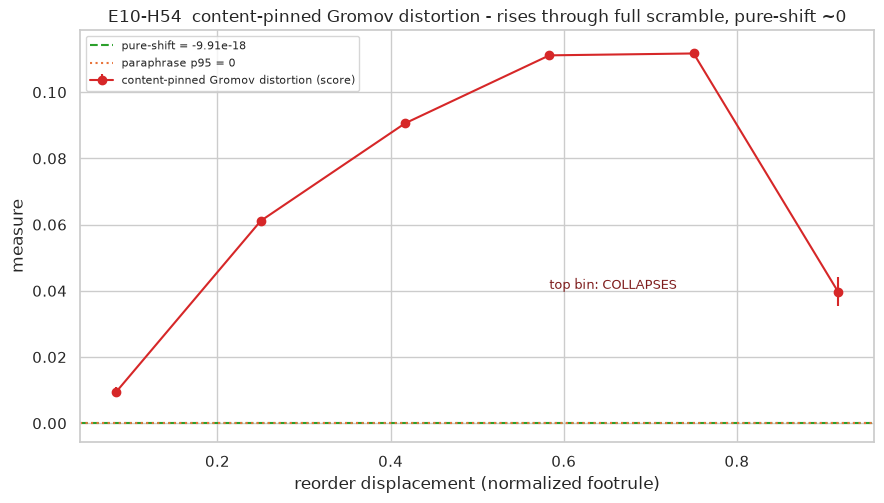

H54 shift -0.0 | spearman 0.429 | top rises False | content_pass True


In [11]:
def plot_hypothesis(col, color, title, fname):
    sc = SCORE[col]; mean, sem = agg(col)
    fig, ax = plt.subplots(figsize=(9, 5.2))
    ax.errorbar(CENTERS, mean, yerr=sem, marker="o", color=color, label=f"{HEAD[col]} ({KIND[col]})")
    ax.axhline(sc["shift_value"], color=COL["shift"], ls="--",
               label=f"pure-shift = {sc['shift_value']:.3g}")
    ax.axhline(sc["paraphrase"]["p95"], color=COL["para"], ls=":",
               label=f"paraphrase p95 = {sc['paraphrase']['p95']:.3g}")
    top = sc["scramble"]["top_bin_mean"]
    ax.annotate("top bin: " + ("rises" if sc["scramble"]["top_bin_rising"] else "COLLAPSES"),
                xy=(CENTERS[-1], mean[-1]), xytext=(CENTERS[-3], top * 1.02), fontsize=9,
                color="#7f1d1d" if sc["scramble"]["collapses_at_full_scramble"] else "#1a7f37")
    ax.set(title=title, xlabel="reorder displacement (normalized footrule)", ylabel="measure")
    ax.legend(fontsize=8)
    plt.tight_layout(); fig.savefig(FIGDIR / fname, dpi=120, bbox_inches="tight"); plt.show()
    return sc

sc = plot_hypothesis("h54", COL["h54"],
    "E10-H54  content-pinned Gromov distortion - rises through full scramble, pure-shift ~0", "e10-h54-pinned-gw.png")
RESULTS["E10-H54"] = {"kind": KIND["h54"], "metric_or_score": "score",
    "spearman": sc["scramble"]["spearman"], "top_bin_rising": sc["scramble"]["top_bin_rising"],
    "collapses": sc["scramble"]["collapses_at_full_scramble"], "shift_value": sc["shift_value"],
    "shift_pass": sc["shift_pass"], "paraphrase_p95": sc["paraphrase"]["p95"],
    "paraphrase_median": sc["paraphrase"]["median"], "content_pass": sc["content_pass"],
    "triangle_viol": TRI["h54"], "diffuse_median": sc["diffuse"]["median"],
    "per_bin_mean": sc["scramble"]["per_bin_mean"]}
print("H54 shift", round(sc["shift_value"],4), "| spearman", round(sc["scramble"]["spearman"],3),
      "| top rises", sc["scramble"]["top_bin_rising"], "| content_pass", sc["content_pass"])

## E10-H55 - OPW order-gap

Su & Hua order-preserving Wasserstein (Sinkhorn matrix scaling) under the metric ground cost, minus SMD. The
gap is the extra transport cost the temporal-order regularization imposes; a reorder fights the diagonal
prior so the gap grows. OPW re-derives index positions internally, so it is blind to an absolute shift (the
pure shift is invisible to it). A score - the KL temporal prior makes it a divergence, not a metric.

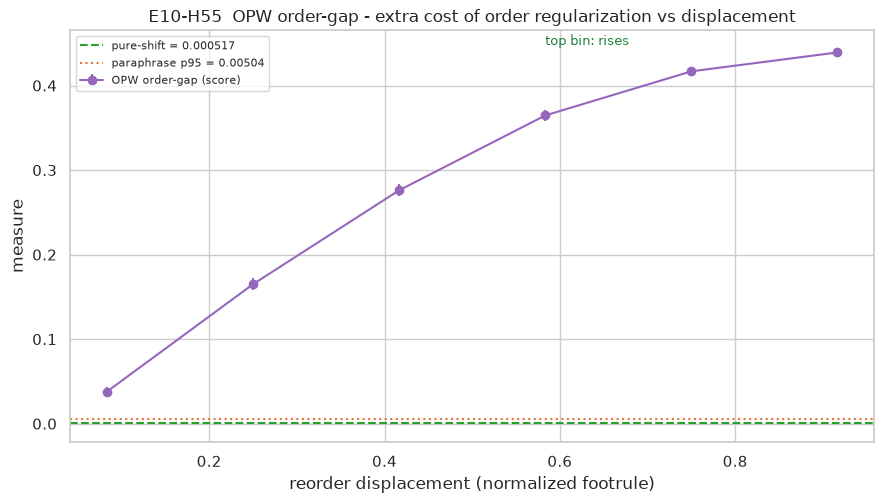

H55 shift 0.0005 | spearman 1.0 | top rises True | content_pass True


In [12]:
sc = plot_hypothesis("h55", COL["h55"],
    "E10-H55  OPW order-gap - extra cost of order regularization vs displacement", "e10-h55-opw-gap.png")
RESULTS["E10-H55"] = {"kind": KIND["h55"], "metric_or_score": "score",
    "spearman": sc["scramble"]["spearman"], "top_bin_rising": sc["scramble"]["top_bin_rising"],
    "collapses": sc["scramble"]["collapses_at_full_scramble"], "shift_value": sc["shift_value"],
    "shift_pass": sc["shift_pass"], "shift_note": "OPW is index-intrinsic; absolute shift is invisible to it",
    "paraphrase_p95": sc["paraphrase"]["p95"], "paraphrase_median": sc["paraphrase"]["median"],
    "content_pass": sc["content_pass"], "triangle_viol": TRI["h55"],
    "diffuse_median": sc["diffuse"]["median"], "per_bin_mean": sc["scramble"]["per_bin_mean"],
    "opw_defaults": {"lambda1": OPW_L1, "lambda2": OPW_L2, "sigma": OPW_SIGMA,
                     "stabilization": "global log-max shift (transport-invariant; preserves lambda2=0.1)"}}
print("H55 shift", round(sc["shift_value"],4), "| spearman", round(sc["scramble"]["spearman"],3),
      "| top rises", sc["scramble"]["top_bin_rising"], "| content_pass", sc["content_pass"])

## E10-H56 - source-anchored ordering divergence

Each document encoded as its reading-order sequence of source-bin indices (the soft-argmax coverage over the
shared 62-statement source), then the Kendall-tau-sequence distance between the two sequences on the shared
source alphabet. Reorder permutes the index sequence (rises with displacement); a pure shift and a paraphrase
leave the coverage sequence unchanged. A metric - both the shared-source and the one-doc-anchor variants are
reported.

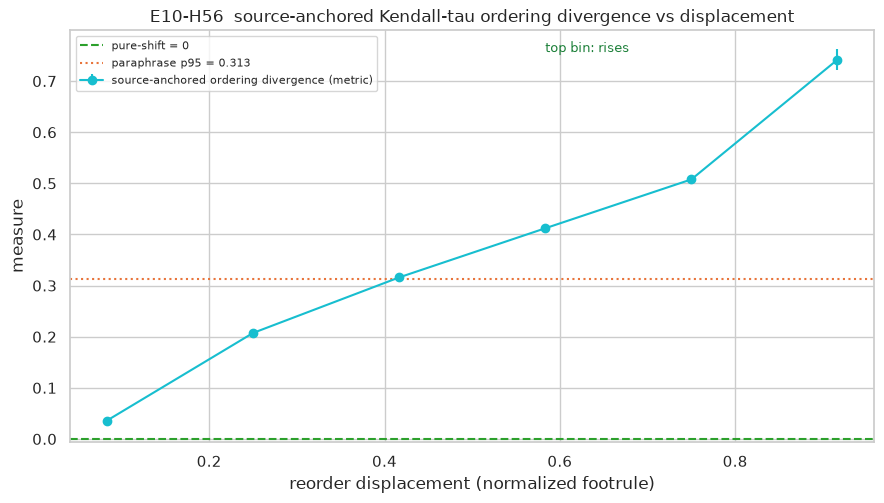

H56 shared shift 0.0 | spearman 1.0 | top rises True | eqlen triangle 0.0 | anchor spearman 1.0


In [13]:
sc = plot_hypothesis("h56", COL["h56"],
    "E10-H56  source-anchored Kendall-tau ordering divergence vs displacement", "e10-h56-source-kendalltau.png")
sc_anchor = score_measure("h56a")
RESULTS["E10-H56"] = {"kind": KIND["h56"], "metric_or_score": "metric",
    "spearman": sc["scramble"]["spearman"], "top_bin_rising": sc["scramble"]["top_bin_rising"],
    "collapses": sc["scramble"]["collapses_at_full_scramble"], "shift_value": sc["shift_value"],
    "shift_pass": sc["shift_pass"], "paraphrase_p95": sc["paraphrase"]["p95"],
    "paraphrase_median": sc["paraphrase"]["median"], "content_pass": sc["content_pass"],
    "triangle_viol_eqlen": TRI["h56_eqlen"], "triangle_viol_diffuse": TRI["h56_diffuse"],
    "diffuse_median": sc["diffuse"]["median"], "per_bin_mean": sc["scramble"]["per_bin_mean"],
    "anchor_variant": {"spearman": sc_anchor["scramble"]["spearman"],
                       "top_bin_rising": sc_anchor["scramble"]["top_bin_rising"],
                       "shift_value": sc_anchor["shift_value"],
                       "paraphrase_p95": sc_anchor["paraphrase"]["p95"],
                       "diffuse_median": sc_anchor["diffuse"]["median"]}}
print("H56 shared shift", round(sc["shift_value"],4), "| spearman", round(sc["scramble"]["spearman"],3),
      "| top rises", sc["scramble"]["top_bin_rising"], "| eqlen triangle", round(TRI["h56_eqlen"],3),
      "| anchor spearman", round(sc_anchor["scramble"]["spearman"],3))

## E10-H57 - shared-codebook edit distance

Co-cluster the pooled A+B statements into shared symbols (agglomerative on the $\sqrt{2-2\cos}$ cost,
distance threshold), encode each document as its symbol string in reading order, read the
Kendall-tau-sequence between the two strings. A paraphrase maps to the same symbols ($\approx 0$); a reorder
permutes the string (large). Non-OT, table-turning. A metric - gated by the bootstrap symbol-assignment
stability (flag if ARI < 0.9, the E09 small-N lesson).

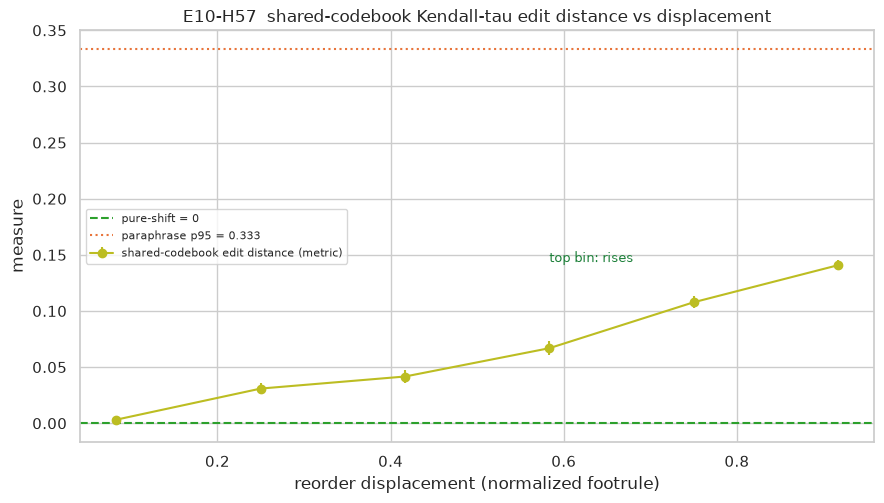

H57 shift 0.0 | spearman 1.0 | top rises True | eqlen triangle 0.0 | stability ARI 0.872


In [14]:
sc = plot_hypothesis("h57", COL["h57"],
    "E10-H57  shared-codebook Kendall-tau edit distance vs displacement", "e10-h57-codebook-edit.png")
RESULTS["E10-H57"] = {"kind": KIND["h57"], "metric_or_score": "metric",
    "spearman": sc["scramble"]["spearman"], "top_bin_rising": sc["scramble"]["top_bin_rising"],
    "collapses": sc["scramble"]["collapses_at_full_scramble"], "shift_value": sc["shift_value"],
    "shift_pass": sc["shift_pass"], "paraphrase_p95": sc["paraphrase"]["p95"],
    "paraphrase_median": sc["paraphrase"]["median"], "content_pass": sc["content_pass"],
    "triangle_viol_eqlen": TRI["h57_eqlen"], "triangle_viol_diffuse": TRI["h57_diffuse"],
    "diffuse_median": sc["diffuse"]["median"], "per_bin_mean": sc["scramble"]["per_bin_mean"],
    "codebook_threshold": CODEBOOK_THRESH, "bootstrap_stability_ari": H57_STABILITY,
    "stability_pass": bool(H57_STABILITY >= 0.9), "mean_n_symbols": H57_NSYM}
print("H57 shift", round(sc["shift_value"],4), "| spearman", round(sc["scramble"]["spearman"],3),
      "| top rises", sc["scramble"]["top_bin_rising"], "| eqlen triangle", round(TRI["h57_eqlen"],3),
      "| stability ARI", round(H57_STABILITY,3))

## E10-H58 - soft-DTW divergence order-gap

Blondel-Mensch-Vert soft-DTW divergence (non-negative, zero iff equal) under the SMD ground cost, minus SMD.
soft-DTW enforces a monotonic alignment, so a reorder inflates its cost while the order-free SMD on identical
content stays 0; the gap is the monotonic-alignment penalty. DTW is blind to absolute position, so a pure
shift reads 0. A score (a divergence, not a metric).

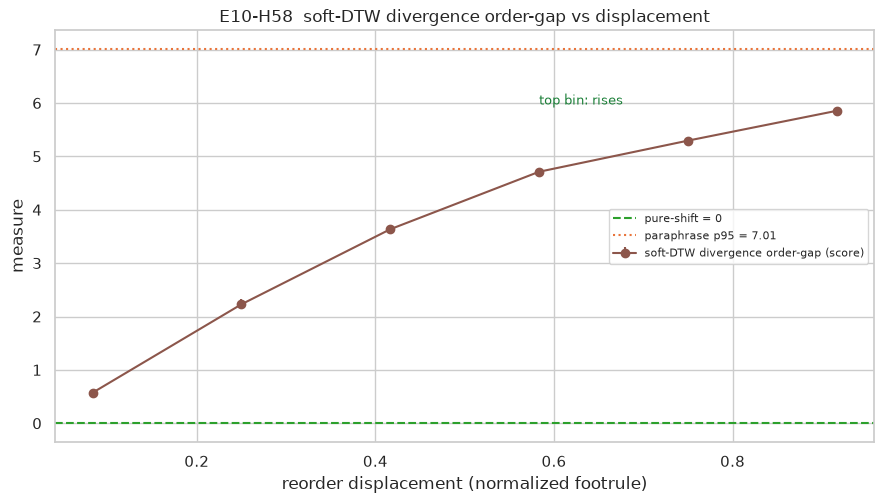

H58 shift 0.0 | spearman 1.0 | top rises True | content_pass False


In [15]:
sc = plot_hypothesis("h58", COL["h58"],
    "E10-H58  soft-DTW divergence order-gap vs displacement", "e10-h58-softdtw-gap.png")
RESULTS["E10-H58"] = {"kind": KIND["h58"], "metric_or_score": "score",
    "spearman": sc["scramble"]["spearman"], "top_bin_rising": sc["scramble"]["top_bin_rising"],
    "collapses": sc["scramble"]["collapses_at_full_scramble"], "shift_value": sc["shift_value"],
    "shift_pass": sc["shift_pass"], "paraphrase_p95": sc["paraphrase"]["p95"],
    "paraphrase_median": sc["paraphrase"]["median"], "content_pass": sc["content_pass"],
    "triangle_viol": TRI["h58"], "diffuse_median": sc["diffuse"]["median"], "gamma": GAMMA,
    "per_bin_mean": sc["scramble"]["per_bin_mean"]}
print("H58 shift", round(sc["shift_value"],4), "| spearman", round(sc["scramble"]["spearman"],3),
      "| top rises", sc["scramble"]["top_bin_rising"], "| content_pass", sc["content_pass"])

## E10 summary - the two new-property axes

The decisive comparison. Left: every measure's per-bin curve (normalized to its own top-bin value) so the
shapes - rise-through-top vs collapse - are visible on one axis, with the E08-H44 posaug and naive baselines
overlaid. Right: the combined-property scatter - x is the pure-shift value normalized by the reorder top-bin
mean (0 = translation-invariant), y is the scramble Spearman; a filled marker means the curve rises through
the top bin. A winner sits at the bottom-left with a filled marker: shift $\approx 0$ AND monotone through
the top. E08-H44 posaug sits to the right (shift failure); any collapsing measure has a hollow marker.

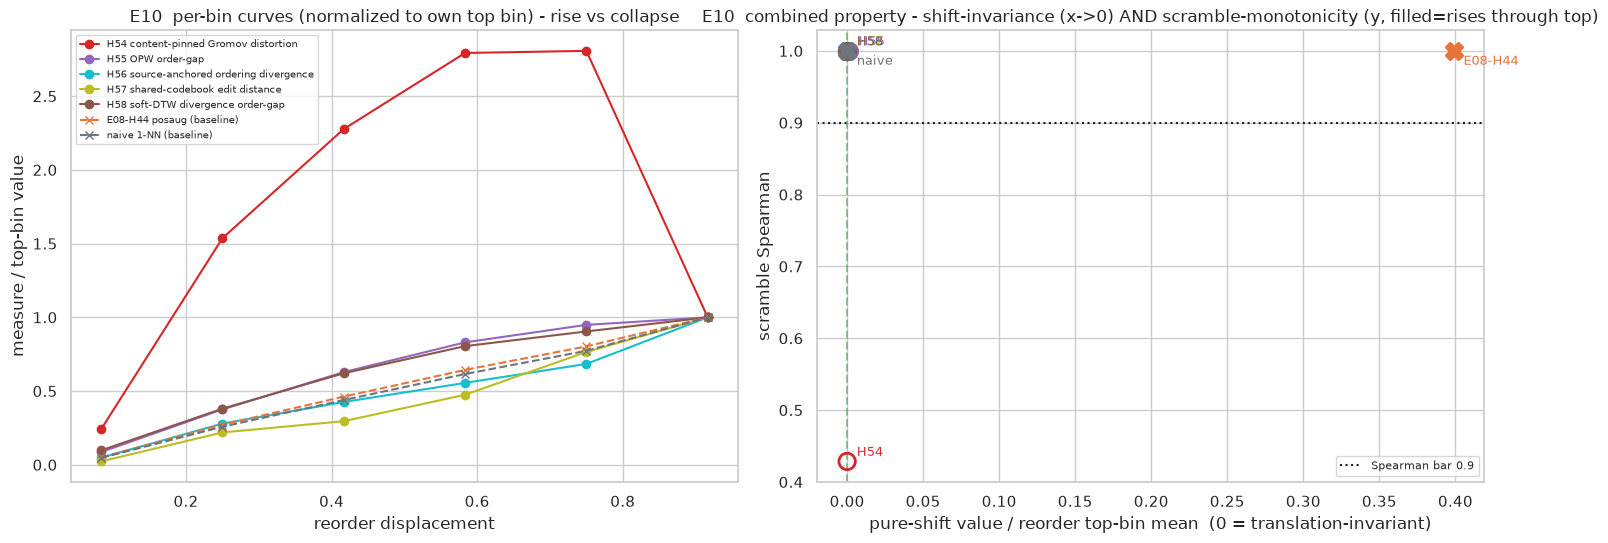

summary panel written


In [16]:
fig, ax = plt.subplots(1, 2, figsize=(15.5, 5.6))

# left: per-bin curves normalized to own top-bin value
for c in MECH:
    mean, _ = agg(c); denom = mean[-1] if abs(mean[-1]) > 1e-12 else 1.0
    ax[0].plot(CENTERS, mean / denom, marker="o", color=COL[c], label=f"{c.upper()} {HEAD[c]}")
for c in ["paug", "naive"]:
    mean, _ = agg(c); denom = mean[-1] if abs(mean[-1]) > 1e-12 else (np.nanmax(np.abs(mean)) or 1.0)
    ax[0].plot(CENTERS, mean / denom, marker="x", ls="--", color=COL[c],
               label=f"{'E08-H44 posaug' if c=='paug' else 'naive 1-NN'} (baseline)")
ax[0].set(title="E10  per-bin curves (normalized to own top bin) - rise vs collapse",
          xlabel="reorder displacement", ylabel="measure / top-bin value"); ax[0].legend(fontsize=7)

# right: combined-property scatter
def pt(sc):
    top = abs(sc["scramble"]["top_bin_mean"])
    return sc["shift_value"] / (top + 1e-12), sc["scramble"]["spearman"], sc["scramble"]["top_bin_rising"]
for c in MECH:
    x, y, rising = pt(SCORE[c])
    ax[1].scatter([x], [y], s=140, color=COL[c], marker="o",
                  facecolors=COL[c] if rising else "none", edgecolors=COL[c], linewidths=2, zorder=5)
    ax[1].annotate(c.upper(), (x, y), textcoords="offset points", xytext=(7, 4), fontsize=9, color=COL[c])
for c in ["paug", "naive"]:
    x, y, rising = pt(BASELINE[c])
    ax[1].scatter([x], [y], s=140, color=COL[c], marker="X",
                  facecolors=COL[c] if rising else "none", edgecolors=COL[c], linewidths=2, zorder=5)
    ax[1].annotate("E08-H44" if c == "paug" else "naive", (x, y),
                   textcoords="offset points", xytext=(7, -10), fontsize=9, color=COL[c])
ax[1].axhline(MONO_BAR, color=COL["chance"], ls=":", label=f"Spearman bar {MONO_BAR}")
ax[1].axvline(0.0, color=COL["shift"], ls="--", alpha=0.5)
ax[1].set(title="E10  combined property - shift-invariance (x->0) AND scramble-monotonicity (y, filled=rises through top)",
          xlabel="pure-shift value / reorder top-bin mean  (0 = translation-invariant)",
          ylabel="scramble Spearman"); ax[1].legend(fontsize=8, loc="lower right")
plt.tight_layout(); fig.savefig(FIGDIR / "e10-summary.png", dpi=120, bbox_inches="tight"); plt.show()
print("summary panel written")

## Verdicts and conclusions

In [17]:
def verdict_for(col):
    r = RESULTS[f"E10-{col.upper()}"]
    sc = SCORE[col]
    is_metric = KIND[col] == "metric"
    tri0 = (TRI[f"{col}_eqlen"] <= 1e-9) if is_metric else True
    shift_pass = sc["shift_pass"]; monotone_pass = sc["monotone_pass"]; content_pass = sc["content_pass"]
    combined = shift_pass and monotone_pass
    confirmed = combined and content_pass and tri0
    stability_ok = (col != "h57") or (H57_STABILITY >= 0.9)
    if confirmed and stability_ok:
        verdict = "Confirmed"
    elif combined and (content_pass or not is_metric):
        verdict = "Inconclusive"      # holds the combined property but a secondary gate is soft
    elif not combined:
        verdict = "Refuted"           # fails the combined property outright
    else:
        verdict = "Inconclusive"
    # applicability
    beats_h44 = combined and not PAUG_HAS_BOTH
    if verdict == "Confirmed":
        app = "high" if (is_metric and stability_ok) else "medium"
        if col == "h57" and not stability_ok:
            app = "low"
    elif verdict == "Inconclusive":
        app = "low"
    else:
        app = "none"
    return {"verdict": verdict, "applicability": app, "metric_or_score": KIND[col],
            "shift_pass": bool(shift_pass), "monotone_pass": bool(monotone_pass),
            "content_pass": bool(content_pass), "combined_property": bool(combined),
            "triangle_zero": bool(tri0), "beats_E08_H44_on_combined": bool(beats_h44),
            "headline": (f"shift {sc['shift_value']:.3g} vs paraphrase p95 {sc['paraphrase']['p95']:.3g} "
                         f"({'PASS' if shift_pass else 'FAIL'}); Spearman {sc['scramble']['spearman']:.2f}, "
                         f"top bin {'rises' if sc['scramble']['top_bin_rising'] else 'COLLAPSES'} "
                         f"({'PASS' if monotone_pass else 'FAIL'}); paraphrase median "
                         f"{sc['paraphrase']['median']:.3g} ({'PASS' if content_pass else 'FAIL'}); "
                         f"triangle {'0' if tri0 else 'nonzero'}")}

for col in MECH:
    VERDICTS[f"E10-{col.upper()}"] = verdict_for(col)

# winners: any Confirmed; prefer metric then widest scramble dynamic range
confirmed = [c for c in MECH if VERDICTS[f"E10-{c.upper()}"]["verdict"] == "Confirmed"]
def rangeq(c):
    sc = SCORE[c]; top = abs(sc["scramble"]["top_bin_mean"]); base = sc["scramble"]["per_bin_mean"][0]
    return top - abs(base)
winner = None
if confirmed:
    winner = sorted(confirmed, key=lambda c: (KIND[c] == "metric", rangeq(c)), reverse=True)[0]

t = Table(title="E10 verdicts - the combined property (shift-invariance AND scramble-monotonicity)",
          title_style="bold green")
for c in ("hypothesis", "verdict", "applic.", "kind", "shift", "scramble", "content", "tri", "beats H44"):
    t.add_column(c, overflow="fold", style="cyan" if c == "hypothesis" else None)
for col in MECH:
    v = VERDICTS[f"E10-{col.upper()}"]; sc = SCORE[col]
    t.add_row(f"E10-{col.upper()}\n{HEAD[col]}", v["verdict"], v["applicability"], v["metric_or_score"],
              ("PASS" if v["shift_pass"] else "FAIL") + f" {sc['shift_value']:.2g}",
              ("PASS" if v["monotone_pass"] else "FAIL") + f" r={sc['scramble']['spearman']:.2f}"
              + ("" if sc['scramble']['top_bin_rising'] else " collapse"),
              "PASS" if v["content_pass"] else "FAIL",
              "0" if v["triangle_zero"] else "x",
              "yes" if v["beats_E08_H44_on_combined"] else "no")
console.print(t)
print("Confirmed:", confirmed, "| winner:", winner)
print("E08-H44 posaug holds combined property:", PAUG_HAS_BOTH,
      "| naive holds combined property:", BASELINE["naive"]["combined_property"])

                 E10 verdicts - the combined property (shift-invariance AND scramble-monotonicity)                 
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━┳━━━━━━━━━━━┓
┃ hypothesis      ┃ verdict      ┃ applic. ┃ kind   ┃ shift         ┃ scramble        ┃ content ┃ tri ┃ beats H44 ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━╇━━━━━━━━━━━┩
│ E10-H54         │ Refuted      │ none    │ score  │ PASS -9.9e-18 │ FAIL r=0.43     │ PASS    │ 0   │ no        │
│ content-pinned  │              │         │        │               │ collapse        │         │     │           │
│ Gromov          │              │         │        │               │                 │         │     │           │
│ distortion      │              │         │        │               │                 │         │     │           │
│ E10-H55         │ Confirmed    │ medium  │ score  │ PASS 0.00052  │ PASS r=1.00     │ PASS    │ 0   │ yes       │
│ OPW order-gap   │              │         │        │               │                 │         │     │           │
│ E10-H56         │ Inconclusive │ low     │ metric │ PASS 0        │ PASS r=1.00     │ FAIL    │ 0   │ yes       │
│ source-anchored │              │         │        │               │                 │         │     │           │
│ ordering        │              │         │        │               │                 │         │     │           │
│ divergence      │              │         │        │               │                 │         │     │           │
│ E10-H57         │ Inconclusive │ low     │ metric │ PASS 0        │ PASS r=1.00     │ FAIL    │ 0   │ yes       │
│ shared-codebook │              │         │        │               │                 │         │     │           │
│ edit distance   │              │         │        │               │                 │         │     │           │
│ E10-H58         │ Inconclusive │ low     │ score  │ PASS 0        │ PASS r=1.00     │ FAIL    │ 0   │ yes       │
│ soft-DTW        │              │         │        │               │                 │         │     │           │
│ divergence      │              │         │        │               │                 │         │     │           │
│ order-gap       │              │         │        │               │                 │         │     │           │
└─────────────────┴──────────────┴─────────┴────────┴───────────────┴─────────────────┴─────────┴─────┴───────────┘

Confirmed: ['h55'] | winner: h55
E08-H44 posaug holds combined property: False | naive holds combined property: True


In [18]:
payload = {
    "results": RESULTS,
    "verdicts": VERDICTS,
    "config": {
        "n_bins": N_BINS, "per_bin": PER_BIN, "bases": BASE_DOCS, "shifts": SHIFTS,
        "gamma": GAMMA, "opw": {"lambda1": OPW_L1, "lambda2": OPW_L2, "sigma": OPW_SIGMA},
        "paraphrase_target_cos": PARA_COS, "paraphrase_realized_cos": PARA_REALIZED_COS,
        "paraphrase_draws_per_base": PARA_DRAWS, "codebook_threshold": CODEBOOK_THRESH,
        "lam_baseline": LAM_BASE, "mono_bar": MONO_BAR, "content_frac": CONTENT_FRAC,
        "device": DEVICE,
        "baselines": {"posaug_combined_property": PAUG_HAS_BOTH,
                      "posaug_shift_value": BASELINE["paug"]["shift_value"],
                      "posaug_shift_norm": BASELINE["paug"]["shift_norm"],
                      "posaug_scramble_spearman": BASELINE["paug"]["scramble"]["spearman"],
                      "naive_combined_property": BASELINE["naive"]["combined_property"],
                      "naive_shift_value": BASELINE["naive"]["shift_value"],
                      "naive_shift_norm": BASELINE["naive"]["shift_norm"],
                      "naive_scramble_spearman": BASELINE["naive"]["scramble"]["spearman"]},
        "winner": winner, "confirmed": confirmed,
        "regime": "byte-identical reorder upper bound + pure-shift + embedding paraphrase proxy "
                  "(true-paraphrase deferred, no API key) + cross-summary diffuse",
        "triangle_rates": TRI,
    },
}
REPORT.write_text(json.dumps(payload, indent=2))
print("wrote", REPORT)

wrote /home/lab/workspace/learning/projects/docdistance/reports/E10-structure-sensitive-metrics.json


## Conclusions

The E10 batch tests whether any single structure read holds **both** halves of the property neither E08
survivor had - translation-invariance (a pure positional shift reads $\approx 0$) **and**
scramble-monotonicity (the curve rises through the top displacement bin) - while staying blind to a content
paraphrase. The decisive evidence is the combined-property scatter: a winner sits at shift $\approx 0$ with a
Spearman above the bar and a curve that still rises at full scramble, where E08-H44 (position-augmented
Wasserstein) fails the shift axis and E08-H45 (positional FGW) collapsed at the top bin.

Every number on the reorder axis is the **byte-identical reorder upper bound**; the paraphrase control is an
**embedding-space proxy** (the true LLM paraphrase floor is deferred - no API key), and the cross-summary
pairs are the realistic diffuse regime. The standing deferrals from E07/E08 (real-conversion-pair gate, LLM
paraphrase floor, second-article replication, hyperparameter selection) carry over unchanged.